# Gemini API: Building a MCP Server

## Overview

While LLMs are powerful, their actions are limited to content generation. To enable them to interact with the world, perform tasks, and access real-time information, whether it's reading a file, querying a database, or making an API call, we can use [MCP](https://modelcontextprotocol.io/overview) (Model Context Protocol) which is a standardized way for LLMs to interact with external systems.

The [MCP](https://modelcontextprotocol.io/docs/getting-started/intro) protocol was designed by [anthropic](https://www.anthropic.com/) as a standard way for AI applications and agents to connect to and work with your data sources (e.g. local files, databases, or content repositories) and tools (e.g. GitHub, Google Maps, or Puppeteer).

## How does it work?

At a very high level, MCP has three participants:

- **MCP Client**: A component that maintains a connection to the MCP server and obtains context from an MCP server for the MCP host to use, it can also invoke tools and read resources from the MCP server.
- **MCP Host**: The AI application that coordinates and manages one or more MCP clients, e.g. Claude Desktop, VS Code etc.
- **MCP Server**: A remote or a local server that provides context to the MCP client, it can do so by exposing tools, resources and prompts.

![MCP Protocol](https://mintlify.s3.us-west-1.amazonaws.com/mcp/images/mcp-simple-diagram.png)


## Setup

### Install the Google GenAI SDK

Install the Google GenAI SDK from [npm](https://www.npmjs.com/package/@google/genai). 

```bash
$ npm install @google/genai
```

### Setup your API key

You can [create](https://aistudio.google.com/app/apikey) your API key using Google AI Studio with a single click.

Remember to treat your API key like a password. Don't accidentally save it in a notebook or source file you later commit to GitHub. In this notebook we will be storing the API key in a `.env` file. You can also set it as an environment variable or use a secret manager. 

Here's how to set it up in a `.env` file:

```bash
$ touch .env
$ echo "GEMINI_API_KEY=<YOUR_API_KEY>" >> .env
```

:::{.callout-tip}

Another option is to set the API key as an environment variable. You can do this in your terminal with the following command:

```bash
$ export GEMINI_API_KEY="<YOUR_API_KEY>"
```
:::

### Load the API key

To load the API key from the `.env` file, we will use the `dotenv` package. This package loads environment variables from a `.env` file into `process.env`. 

```bash
$ npm install dotenv
```

Then, we can load the API key in our code:


In [5]:
const dotenv = require("dotenv") as typeof import("dotenv");

dotenv.config({
  path: "../../.env",
});

const GEMINI_API_KEY = process.env.GEMINI_API_KEY ?? "";
if (!GEMINI_API_KEY) {
  throw new Error("GEMINI_API_KEY is not set in the environment variables");
}
console.log("GEMINI_API_KEY is set in the environment variables");


GEMINI_API_KEY is set in the environment variables


:::{.callout-note}
In our particular case the `.env` is is two directories up from the notebook, hence we need to use `../../` to go up two directories. If the `.env` file is in the same directory as the notebook, you can omit it altogether.

```
│
├── .env
└── examples
    └── mcp
        └── Building_a_MCP_server.ipynb
```
:::


### Select a model

Now select the model you want to use in this guide, either by selecting one in the list or writing it down. Keep in mind that some models, like the 2.5 ones are thinking models and thus take slightly more time to respond (cf. [thinking notebook](../../quickstarts/Get_started_thinking.ipynb) for more details and in particular learn how to switch the thiking off).


In [6]:
const tslab = require("tslab") as typeof import("tslab");

const MODEL_ID = "gemini-2.0-flash";


### Initialize SDK Client

With the new SDK, now you only need to initialize a client with you API key (or OAuth if using [Vertex AI](https://cloud.google.com/vertex-ai)). The model is now set in each call.


In [7]:
const google = require("@google/genai") as typeof import("@google/genai");

const ai = new google.GoogleGenAI({ apiKey: GEMINI_API_KEY });


## Defining a MCP server

In this example, you will create a simple MCP server that provides an interface to interact with and query the popular Pokemon API [PokeAPI](https://github.com/PokeAPI/pokeapi). 

You will create a `McpServer` instance and register a set of tools that the MCP server will expose. The Gemini model will be able to query the list of available tools (`tools/list`) and invoke particular tools to retrieve information.


In [8]:
const z = require("zod") as typeof import("zod");
const server =
  require("@modelcontextprotocol/sdk/server/mcp.js") as typeof import("@modelcontextprotocol/sdk/server/mcp.js");

const mcpServer = new server.McpServer({
  name: "PokeAPI MCP Server",
  version: "1.0.0",
});


### Defining `tools` for the MCP server

The MCP server will expose a set of tools that the Gemini model can use to interact with the PokeAPI. You can define these tools using the `registerTool` method of the `McpServer` instance.

:::{.callout-note}

Currently the [js-genai SDK](https://github.com/googleapis/js-genai/tree/main) does not support prompts and resources, so we will only focus on tools in this example. However, you can still use the MCP server to provide prompts and resources by using `registerPrompt` and `registerResource` methods of the `McpServer` instance.

:::


In [ ]:
mcpServer.registerTool(
  "getPokemon",
  {
    title: "Get Pokemon",
    description:
      "Get information about a Pokemon by its name or ID. Details include abilities, stats, sprites, and more.",
    inputSchema: {
      nameOrId: z.string().describe("The name or ID of the Pokemon to retrieve information about."),
    },
  },
  async ({ nameOrId }) => {
    const response = await fetch(`https://pokeapi.co/api/v2/pokemon/${nameOrId}`);
    if (!response.ok) {
      throw new Error(`Failed to fetch Pokemon: ${response.statusText}`);
    }
    return { content: [{ type: "text", text: await response.text() }] };
  }
);

mcpServer.registerTool(
  "getEvolutionChain",
  {
    title: "Get Evolution Chain",
    description: "Get the evolution chain of a Pokemon by its evolution chain ID. (Available from species endpoint)",
    inputSchema: {
      evolutionChainId: z
        .string()
        .describe("The ID of the evolution chain to retrieve. This can be obtained from the species endpoint."),
    },
  },
  async ({ evolutionChainId }) => {
    const response = await fetch(`https://pokeapi.co/api/v2/evolution-chain/${evolutionChainId}`);
    if (!response.ok) {
      throw new Error(`Failed to fetch evolution chain: ${response.statusText}`);
    }
    return { content: [{ type: "text", text: await response.text() }] };
  }
);

mcpServer.registerTool(
  "getPokemonSpecies",
  {
    title: "Get Pokemon Species",
    description: "Get information about a Pokemon species by its name or ID.",
    inputSchema: {
      nameOrId: z.string().describe("The name or ID of the Pokemon species to retrieve information about."),
    },
  },
  async ({ nameOrId }) => {
    const response = await fetch(`https://pokeapi.co/api/v2/pokemon-species/${nameOrId}`);
    if (!response.ok) {
      throw new Error(`Failed to fetch Pokemon species: ${response.statusText}`);
    }
    return { content: [{ type: "text", text: await response.text() }] };
  }
);

mcpServer.registerTool(
  "getItem",
  {
    title: "Get Item",
    description: "Get information about an item by its name or ID.",
    inputSchema: {
      nameOrId: z.string().describe("The name or ID of the item to retrieve information about."),
    },
  },
  async ({ nameOrId }) => {
    const response = await fetch(`https://pokeapi.co/api/v2/item/${nameOrId}`);
    if (!response.ok) {
      throw new Error(`Failed to fetch item: ${response.statusText}`);
    }
    return { content: [{ type: "text", text: await response.text() }] };
  }
);

mcpServer.registerTool(
  "getAbility",
  {
    title: "Get Ability",
    description: "Get information about an ability by its name or ID.",
    inputSchema: {
      nameOrId: z.string().describe("The name or ID of the ability to retrieve information about."),
    },
  },
  async ({ nameOrId }) => {
    const response = await fetch(`https://pokeapi.co/api/v2/ability/${nameOrId}`);
    if (!response.ok) {
      throw new Error(`Failed to fetch ability: ${response.statusText}`);
    }
    return { content: [{ type: "text", text: await response.text() }] };
  }
);

mcpServer.registerTool(
  "getMove",
  {
    title: "Get Move",
    description: "Get information about a move by its name or ID.",
    inputSchema: {
      nameOrId: z.string().describe("The name or ID of the move to retrieve information about."),
    },
  },
  async ({ nameOrId }) => {
    const response = await fetch(`https://pokeapi.co/api/v2/move/${nameOrId}`);
    if (!response.ok) {
      throw new Error(`Failed to fetch move: ${response.statusText}`);
    }
    return { content: [{ type: "text", text: await response.text() }] };
  }
);

console.log("Tools registered successfully");


Tools registered successfully


## Creating a MCP Client

In this section, you will create a MCP client that connects to the MCP server and invokes the tools exposed by the server. The `js-genai` SDK provides a `mcpToTool` function that allows you to convert a MCP tool to Gemini tools.


In [10]:
const client =
  require("@modelcontextprotocol/sdk/client/index.js") as typeof import("@modelcontextprotocol/sdk/client/index.js");

const mcpClient = new client.Client({
  name: "PokeAPI MCP Client",
  version: "1.0.0",
});


## Connecting to the MCP server

The MCP server and client communicate over a particular transports. The MCP typescript-sdk provided an `InMemoryTransport` that allows you to run the MCP server and client in the same process. This is useful for testing and development purposes.


In [11]:
const transport =
  require("@modelcontextprotocol/sdk/inMemory.js") as typeof import("@modelcontextprotocol/sdk/inMemory.js");

const transports = transport.InMemoryTransport.createLinkedPair();

await mcpServer.connect(transports[0]);
await mcpClient.connect(transports[1]);


## Experimenting with Tools

### Manually invoking tools

You can manually invoke the tools exposed by the MCP server using the `callTool` method of the `McpClient` instance. This allows you to test the tools and see how they work before using them in a Gemini model.


In [ ]:
type CallToolResult = Awaited<ReturnType<typeof mcpClient.callTool>>;

const result: CallToolResult = await mcpClient.callTool({
  name: "getPokemon",
  arguments: {
    nameOrId: "pikachu",
  },
});
console.log(`${(result.content as { text: string }[])[0].text.slice(0, 200)}...`);


{"abilities":[{"ability":{"name":"static","url":"https://pokeapi.co/api/v2/ability/9/"},"is_hidden":false,"slot":1},{"ability":{"name":"lightning-rod","url":"https://pokeapi.co/api/v2/ability/31/"},"i...


As you can see, the `callTool` method takes a tool name and its arguments, and returns the result of the tool invocation. In this case, the tool is working as expected and returns the information about the Pokemon with the name `"pikachu"`.


### Integrating with Gemini

Now that you have a MCP server and client set up, you can integrate it with a Gemini model. The `js-genai` SDK provides a `mcpToTool` function that takes a MCP client instance and returns a list of Gemini tools that can be used in a Gemini model.


In [ ]:
const mcpChat = ai.chats.create({
  model: MODEL_ID,
  config: {
    tools: [google.mcpToTool(mcpClient)],
    toolConfig: {
      functionCallingConfig: {
        mode: google.FunctionCallingConfigMode.AUTO,
      },
    },
  },
});


Let's create a few utility functions to help us with the integration. These functions will allow you to view the order of function calls and the results of the tool invocations. This will help us understand the reasoning behind the results provided by the Gemini model.


In [14]:
import { Content, FunctionResponse } from "@google/genai";

function printFunctionResponse(response: FunctionResponse) {
  const result = response.response;
  if (result.content) {
    for (const content of result.content as { text: string }[]) {
      if (content.text) {
        content.text = `${content.text.slice(0, 200)}...`;
      }
    }
  }
  console.log("Function Response\n");
  console.log(JSON.stringify(result, null, 2));
}

function printFunctionCallingHistory(history: Content[]) {
  for (const content of history) {
    for (const part of content.parts ?? []) {
      if (part.functionCall) {
        console.log("Function Call\n");
        console.log(JSON.stringify(part.functionCall, null, 2));
      }
      if (part.functionResponse) {
        printFunctionResponse(part.functionResponse);
      }
    }
  }
}


In [17]:
// temporarily make console.warn a no-op to avoid warnings in the output (non-text part in GenerateContentResponse caused by accessing .text)
// https://github.com/googleapis/js-genai/blob/d82aba244bdb804b063ef8a983b2916c00b901d2/src/types.ts#L2005
// copy the original console.warn function to restore it later
const warn_fn = console.warn;
// eslint-disable-next-line @typescript-eslint/no-empty-function, no-empty-function
console.warn = function () {};

const response_1 = await mcpChat.sendMessage({
  message: "Can you provide the showdown sprites for the pokemon Pikachu?",
});
tslab.display.markdown(response_1.text ?? "");

printFunctionCallingHistory(response_1.automaticFunctionCallingHistory ?? []);


Here are the links to the showdown sprites for Pikachu:

*   **Default:** https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/other/showdown/25.gif
*   **Female:** https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/other/showdown/female/25.gif
*   **Shiny:** https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/other/showdown/shiny/25.gif
*   **Shiny Female:** https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/other/showdown/shiny/female/25.gif
*   **Back Default:** https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/other/showdown/back/25.gif
*   **Back Female:** https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/other/showdown/back/female/25.gif
*   **Back Shiny:** https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/other/showdown/back/shiny/25.gif

Function Call

{
  "name": "getPokemon",
  "args": {
    "nameOrId": "Pikachu"
  }
}
Function Response

{
  "content": [
    {
      "type": "text",
      "text": "{\"abilities\":[{\"ability\":{\"name\":\"static\",\"url\":\"https://pokeapi.co/api/v2/ability/9/\"},\"is_hidden\":false,\"slot\":1},{\"ability\":{\"name\":\"lightning-rod\",\"url\":\"https://pokeapi.co/api/v2/ability/31/\"},\"i..."
    }
  ]
}


In [29]:
function getUrlsFromResponse(response: string): string[] {
  const urlRegex = /https?:\/\/[^\s]+/g;
  const urls = response.match(urlRegex);
  return urls ?? [];
}

const spriteUrls = getUrlsFromResponse(response_1.text ?? "");
tslab.display.html(`<img src="${spriteUrls[0]}" alt="Pikachu Sprite" style="max-width: 200px; max-height: 200px;"/>`);


For comparison, let's ask the Gemini model the same question without using the MCP server.


In [ ]:
const raw_response_1 = await ai.models.generateContent({
  model: MODEL_ID,
  contents: "Can you provide the showdown sprites for pokemon Pikachu?",
});
tslab.display.markdown(raw_response_1.text ?? "");


Since I can't actually *show* you an image, I can provide a detailed textual description of what a showdown-style sprite for Pikachu would look like, focusing on its common battle stance and animated elements:

---

**Pikachu (Showdown Style Sprite Description)**

Pikachu is rendered in a crisp, clean pixel-art style, typical of Pokémon Showdown, facing slightly to the right (as if facing an opponent). Its body is a vibrant, electric yellow, plump and rounded, giving it a sturdy yet agile appearance.

**Key Features & Pose:**

*   **Stance:** Pikachu is poised in a ready-for-battle stance, leaning slightly forward on its short, stubby legs, conveying a sense of anticipation and agility. There's a subtle "bounce" in its posture, implying a continuous, looping animation.
*   **Ears:** Its iconic long, pointed ears stand erect, tipped with sharp black markings that extend down a small portion of the ear. They are slightly angled back, showing alertness.
*   **Cheek Pouches:** The bright, prominent red circular cheek pouches are clearly visible on either side of its face. In an animated sprite, these would subtly flicker or emit tiny, almost imperceptible sparks, indicating its electric power.
*   **Eyes & Expression:** Its small, dark, determined eyes are focused forward, conveying a sense of readiness and resolve. Its mouth is typically a simple, slightly open line or a small, determined arc.
*   **Arms:** Its short, round arms are held slightly out from its body, with tiny, almost indistinguishable fingers, ready to move or gesture.
*   **Tail:** The jagged, lightning-bolt shaped tail is typically held high and slightly arced behind its body, with the distinct patch of brown fur at its base clearly visible. The tail often has a slight sway or subtle "zing" motion in an animation.
*   **Outlines & Shading:** The sprite features clear, dark outlines defining its shape, and minimal yet effective shading to give it volume without being overly complex, consistent with Showdown's visual style.

**Overall Impression (as an animated sprite):**

The sprite would continuously loop a subtle animation – a gentle bobbing of its body, a soft flicker in its cheek pouches, perhaps a slight twitch of its tail or ears. This makes Pikachu look alive, energetic, and constantly prepared for action on the battlefield. The colors are bright and distinct, making it instantly recognizable and impactful.

### Multi-tool invocation

Gemini models can invoke multiple tools in a single request. This is useful when you want to gather information from multiple sources or perform multiple actions in a single request, cross-referencing the results of multiple tools.


In [ ]:
const response_2 = await mcpChat.sendMessage({
  message: "What abilities does Pikachu have, and what does each one do?",
});
tslab.display.markdown(response_2.text ?? "");

printFunctionCallingHistory(
  (response_2.automaticFunctionCallingHistory ?? []).slice(response_1.automaticFunctionCallingHistory.length + 1)
);


Pikachu has two abilities: Static and Lightning Rod.

**Static**:
When a Pokémon with Static is hit by a move that makes contact, there is a 30% chance that the attacking Pokémon will be paralyzed. Even Pokémon that are normally immune to Electric-type moves can be paralyzed by this ability. Additionally, if a Pokémon with Static is at the head of your party, there is a 50% chance of encountering an Electric-type Pokémon in the wild, if one is available in the area.

**Lightning Rod**:
A Pokémon with Lightning Rod will draw all single-target Electric-type moves to itself. Instead of taking damage, the Pokémon's Special Attack is raised by one stage. This ability will not redirect a move if the intended target also has Lightning Rod. If multiple Pokémon with this ability are on the field, the one with the highest Speed stat will be the one to redirect the move.

Function Call

{
  "name": "getPokemon",
  "args": {
    "nameOrId": "pikachu"
  }
}
Function Response

{
  "content": [
    {
      "type": "text",
      "text": "{\"abilities\":[{\"ability\":{\"name\":\"static\",\"url\":\"https://pokeapi.co/api/v2/ability/9/\"},\"is_hidden\":false,\"slot\":1},{\"ability\":{\"name\":\"lightning-rod\",\"url\":\"https://pokeapi.co/api/v2/ability/31/\"},\"i..."
    }
  ]
}
Function Call

{
  "name": "getAbility",
  "args": {
    "nameOrId": "static"
  }
}
Function Call

{
  "name": "getAbility",
  "args": {
    "nameOrId": "lightning-rod"
  }
}
Function Response

{
  "content": [
    {
      "type": "text",
      "text": "{\"effect_changes\":[{\"effect_entries\":[{\"effect\":\"Hat außerhalb vom Kampf keinen Effekt.\",\"language\":{\"name\":\"de\",\"url\":\"https://pokeapi.co/api/v2/language/6/\"}},{\"effect\":\"Has no overworld effect.\",\"l..."
    }
  ]
}
Function Response

{
  "content": [
    {
      "type": "text",
      "text": "{\"effect_changes\"

In [ ]:
const response_3 = await mcpChat.sendMessage({
  message: "What is the flavor text for Ralts's species, and what is it's evolution chain and directions?",
});
tslab.display.markdown(response_3.text ?? "");

printFunctionCallingHistory(
  (response_3.automaticFunctionCallingHistory ?? []).slice(response_2.automaticFunctionCallingHistory.length + 1)
);


Ralts's flavor text is: "It is highly attuned to the emotions of people and Pokémon. It hides if it senses hostility."

Ralts's evolution chain is as follows:

1.  Ralts evolves into Kirlia at level 20.
2.  Kirlia can evolve into two different Pokémon:
    *   It evolves into Gardevoir at level 30.
    *   Alternatively, a male Kirlia will evolve into Gallade when a Dawn Stone is used on it.

Function Call

{
  "name": "getPokemonSpecies",
  "args": {
    "nameOrId": "ralts"
  }
}
Function Response

{
  "content": [
    {
      "type": "text",
      "text": "{\"base_happiness\":35,\"capture_rate\":235,\"color\":{\"name\":\"white\",\"url\":\"https://pokeapi.co/api/v2/pokemon-color/9/\"},\"egg_groups\":[{\"name\":\"humanshape\",\"url\":\"https://pokeapi.co/api/v2/egg-group/8/\"},{..."
    }
  ]
}
Function Call

{
  "name": "getEvolutionChain",
  "args": {
    "evolutionChainId": "140"
  }
}
Function Response

{
  "content": [
    {
      "type": "text",
      "text": "{\"baby_trigger_item\":null,\"chain\":{\"evolution_details\":[],\"evolves_to\":[{\"evolution_details\":[{\"gender\":null,\"held_item\":null,\"item\":null,\"known_move\":null,\"known_move_type\":null,\"location\":null,\"min_..."
    }
  ]
}


### Multi-step reasoning & tasks

The Gemini model can also perform multi-step reasoning and tasks. This means that the model can break down a complex task into smaller sub-tasks and invoke multiple tools to complete the task by reasoning about the results of the previous steps.


In [ ]:
const response_4 = await mcpChat.sendMessage({
  message: "What are a list of Pokemon which have the ability 'Dancer' and are 'electric' type?",
});
tslab.display.markdown(response_4.text ?? "");

printFunctionCallingHistory(
  (response_4.automaticFunctionCallingHistory ?? []).slice(response_3.automaticFunctionCallingHistory.length + 1)
);


Oricorio Pom-Pom is the only Pokémon with the ability 'Dancer' and the type 'electric'. Other Oricorio forms have the 'Dancer' ability but different types: Baile Style is Fire/Flying, Pau Style is Psychic/Flying, and Sensu Style is Ghost/Flying.

Function Call

{
  "name": "getAbility",
  "args": {
    "nameOrId": "Dancer"
  }
}
Function Response

{
  "content": [
    {
      "type": "text",
      "text": "{\"effect_changes\":[],\"effect_entries\":[{\"effect\":\"Whenever another Pokémon uses a dance move, this Pokémon will use the same move immediately afterwards.\",\"language\":{\"name\":\"en\",\"url\":\"https://pokeap..."
    }
  ]
}
Function Call

{
  "name": "getPokemon",
  "args": {
    "nameOrId": "oricorio-pom-pom"
  }
}
Function Response

{
  "content": [
    {
      "type": "text",
      "text": "{\"abilities\":[{\"ability\":{\"name\":\"dancer\",\"url\":\"https://pokeapi.co/api/v2/ability/216/\"},\"is_hidden\":false,\"slot\":1}],\"base_experience\":167,\"cries\":{\"latest\":\"https://raw.githubusercontent.com/PokeAP..."
    }
  ]
}
Function Call

{
  "name": "getPokemon",
  "args": {
    "nameOrId": "oricorio-baile"
  }
}
Function Response

{
  "content": [
    {
      "type": "text",
      "text": "{\"abilities\":[{\"

In [ ]:
const response_5 = await mcpChat.sendMessage({
  message:
    "Can you devise a moveset for my Mewtwo? It should be a competitive moveset with elaborate reasoning for each move, take into account utility moves and type coverage of moves. (When you get a pokemon it comes with its moveset of all learnable moves, from there shortlist possible moves (less that 10) and then pick the best 4 moves for the moveset with best utility and coverage for showdown, this descision can be made using the getMove tool to get move information and reasoning).",
});
tslab.display.markdown(response_5.text ?? "");

printFunctionCallingHistory(
  (response_5.automaticFunctionCallingHistory ?? []).slice(response_4.automaticFunctionCallingHistory.length + 1)
);


Of course! Here is a competitive moveset for your Mewtwo, designed for success in Pokémon Showdown:

Mewtwo is a legendary Pokémon with an incredible Special Attack stat of 154 and a blistering Speed stat of 130. This makes it one of the most powerful special sweepers in the game. The goal of this moveset is to maximize its offensive potential while providing coverage against a wide range of opponents.

Let's start by looking at a shortlist of potential moves:

*   **Psystrike**: A powerful Psychic-type special attack that targets the opponent's physical defense.
*   **Aura Sphere**: A Fighting-type special attack that never misses.
*   **Shadow Ball**: A Ghost-type special attack that has a chance to lower the opponent's Special Defense.
*   **Ice Beam**: An Ice-type special attack that has a chance to freeze the opponent.
*   **Flamethrower**: A reliable Fire-type special attack that has a chance to burn the opponent.
*   **Fire Blast**: A more powerful but less accurate version of Flamethrower.
*   **Calm Mind**: A status move that boosts Mewtwo's Special Attack and Special Defense.
*   **Nasty Plot**: A status move that sharply raises Mewtwo's Special Attack.
*   **Recover**: A healing move that restores 50% of Mewtwo's maximum HP.
*   **Taunt**: A utility move that prevents the opponent from using non-damaging moves.

After careful consideration, here are the two best movesets for Mewtwo:

---

### **Moveset 1: The All-Out Attacker**

This moveset focuses on immediate offensive pressure and wide type coverage.

| Move | Type | Category | Power | Accuracy |
| :--- | :--- | :--- | :--- | :--- |
| **Psystrike** | Psychic | Special | 100 | 100% |
| **Aura Sphere** | Fighting | Special | 80 | ∞ |
| **Ice Beam** | Ice | Special | 90 | 100% |
| **Fire Blast** | Fire | Special | 110 | 85% |

**Reasoning:**

*   **Psystrike**: This is Mewtwo's signature move and its primary STAB (Same Type Attack Bonus) attack. It hits incredibly hard and has the unique property of targeting the opponent's physical Defense stat, making it effective against specially defensive Pokémon like Blissey.
*   **Aura Sphere**: This move provides perfect coverage against Dark and Steel-type Pokémon that resist Psystrike. Its never-miss accuracy ensures a reliable hit against evasive opponents.
*   **Ice Beam**: An excellent coverage move that hits Dragon, Ground, Grass, and Flying-type Pokémon for super-effective damage. This is particularly useful against common threats like Dragonite, Garchomp, and Landorus.
*   **Fire Blast**: This move provides powerful coverage against Steel-type Pokémon like Ferrothorn and Scizor, which would otherwise wall this set. For a more reliable option, you can use **Flamethrower** (90 Power, 100% Accuracy).

---

### **Moveset 2: The Calm Mind Sweeper**

This moveset is designed to set up and sweep the opposing team.

| Move | Type | Category | Power | Accuracy |
| :--- | :--- | :--- | :--- | :--- |
| **Calm Mind** | Psychic | Status | - | - |
| **Psystrike** | Psychic | Special | 100 | 100% |
| **Aura Sphere** | Fighting | Special | 80 | ∞ |
| **Recover** | Normal | Status | - | - |

**Reasoning:**

*   **Calm Mind**: This is the core of the set. After one or two uses, Mewtwo's Special Attack and Special Defense will be boosted to incredible levels, making it nearly impossible to stop.
*   **Psystrike**: This move benefits greatly from the Special Attack boosts from Calm Mind. After a boost, it can OHKO (One-Hit KO) a large portion of the metagame.
*   **Aura Sphere**: This move provides essential coverage against Dark and Steel types that might otherwise be able to stop a Psystrike sweep.
*   **Recover**: This move gives Mewtwo the longevity it needs to set up Calm Mind and stay healthy throughout the match. It allows Mewtwo to heal off any damage taken while setting up.

For an even more offensive setup, you can replace **Calm Mind** with **Nasty Plot**, which doubles Mewtwo's Special Attack in a single turn, but at the cost of not boosting its Special Defense.

Both of these movesets are incredibly powerful and can be adapted to your playstyle. Good luck in your battles

Function Call

{
  "name": "getPokemon",
  "args": {
    "nameOrId": "mewtwo"
  }
}
Function Response

{
  "content": [
    {
      "type": "text",
      "text": "{\"abilities\":[{\"ability\":{\"name\":\"pressure\",\"url\":\"https://pokeapi.co/api/v2/ability/46/\"},\"is_hidden\":false,\"slot\":1},{\"ability\":{\"name\":\"unnerve\",\"url\":\"https://pokeapi.co/api/v2/ability/127/\"},\"is_..."
    }
  ]
}
Function Call

{
  "name": "getMove",
  "args": {
    "nameOrId": "psystrike"
  }
}
Function Call

{
  "name": "getMove",
  "args": {
    "nameOrId": "aura-sphere"
  }
}
Function Call

{
  "name": "getMove",
  "args": {
    "nameOrId": "shadow-ball"
  }
}
Function Call

{
  "name": "getMove",
  "args": {
    "nameOrId": "ice-beam"
  }
}
Function Call

{
  "name": "getMove",
  "args": {
    "nameOrId": "flamethrower"
  }
}
Function Call

{
  "name": "getMove",
  "args": {
    "nameOrId": "fire-blast"
  }
}
Function Call

{
  "name": "getMove",
  "args": {
    "nameOrId": "calm-mind"
  }


### Multi-modal Output

Some tools can return multi-modal output, such as images or videos. The Gemini model can handle these outputs and process them accordingly. For example, you can chain multiple models to generate an image based on the output of a previous model, or use a tool that returns an image and then process that image with another model.


In [ ]:
const artwork = await ai.models.generateContent({
  model: MODEL_ID,
  contents: "Can you provide the shiny official artwork sprite for 'Mega Rayquaza'?",
  config: {
    tools: [google.mcpToTool(mcpClient)],
    toolConfig: {
      functionCallingConfig: {
        mode: google.FunctionCallingConfigMode.AUTO,
      },
    },
  },
});
tslab.display.markdown(artwork.text ?? "");


Here is the shiny official artwork sprite for Mega Rayquaza: https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/other/official-artwork/shiny/10079.png

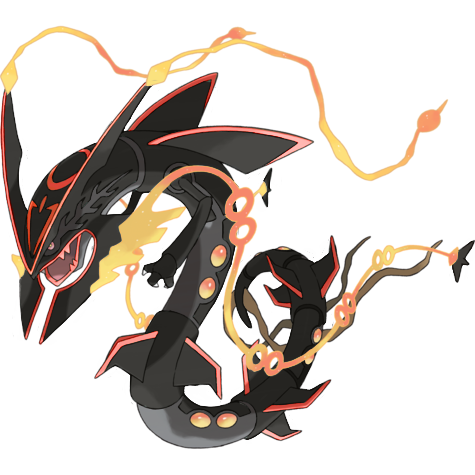

In [51]:
const artworkUrl = getUrlsFromResponse(artwork.text ?? "")[0];
const artworkBlob = await fetch(artworkUrl).then((res) => res.blob());
tslab.display.png(new Uint8Array(await artworkBlob.arrayBuffer()));


In [ ]:
const backgroundDescription = await ai.models.generateContent({
  model: MODEL_ID,
  contents: [
    "Can you provide a detailed description of a background suitable for 'Mega Rayquaza' in a Pokemon game, take the sprite aesthetics into account? Include details about the environment, colors, and any notable features.",
    google.createPartFromBase64(Buffer.from(await artworkBlob.arrayBuffer()).toString("base64"), "image/png"),
  ],
});
tslab.display.markdown(backgroundDescription.text ?? "");


Let's craft a background that perfectly complements Mega Rayquaza's awe-inspiring sprite, emphasizing its cosmic power and imposing presence, while adhering to the stylized nature of a Pokemon game.

**Background Description for Mega Rayquaza**

This background aims to evoke a sense of immense altitude, celestial power, and the volatile energy that defines Mega Rayquaza. It's a dynamic blend of the upper atmosphere and the void of space, serving as a stage for this legendary bringer of order.

---

**1. Overall Environment: The Stratospheric Divide**

The scene depicts a turbulent, yet majestic, view from incredibly high altitudes – specifically, the boundary between Earth's outer atmosphere and the beginnings of deep space. It's not a clear blue sky, but rather a dramatic, twilight-tinged vista where atmospheric phenomena meet cosmic stillness. The angle is slightly looking *down* from Mega Rayquaza's perspective, emphasizing its dominance over the world below.

**2. Color Palette:**

The color scheme is designed to make Mega Rayquaza's prominent black body and vibrant red/orange accents pop with maximum contrast and impact.

*   **Upper Sky/Space (Top 40%):**
    *   **Deep Indigo to Cosmic Black:** The very top fades into a rich, almost inky black, flecked with distant, pinprick stars. Below this, it transitions into deep indigo and dark purples, suggesting the cold void.
    *   **Faint Nebulous Hues:** Swirling subtly within this darkness are faint, ethereal wisps of cosmic dust in very muted, cool tones – perhaps a hint of deep teal, lavender, or a smoky grey, representing distant nebulae or the lingering energy from space. These are *very* desaturated to keep the focus on Rayquaza.
*   **Atmospheric Mid-Ground (Middle 40%):**
    *   **Turbulent Cloud Banks:** A chaotic yet beautiful sea of thick, rolling storm clouds dominates this section. These aren't fluffy white clouds, but rather heavy, bruised, and dynamic formations.
    *   **Color Gradation:**
        *   **Dark Grey-Blues & Purples:** The main body of the clouds is a mixture of dark stormy greys, charcoal, and deep, desaturated blues and purples, giving them immense weight and a brooding quality.
        *   **Fiery Underglow/Edge Lighting:** Crucially, the undersides and prominent edges of these clouds are subtly illuminated by a warm, ethereal glow that emanates from below (representing distant, unseen energy or even the reflected power of Mega Rayquaza itself). This glow ranges from soft, deep orange to a faint fiery red, echoing Rayquaza's own markings.
*   **Lower Horizon/Distant Earth (Bottom 20%):**
    *   **Barely Visible Curvature:** A slight, dark curve of the planet's horizon is visible, hinting at the vastness below.
    *   **Distant Storms/Lightning:** Within this distant lower layer of atmosphere, faint, flickering streaks of lightning can be seen within the clouds, suggesting immense, ongoing storms. These flashes are quick, sharp bursts of bright electric blue or white, providing a dynamic element without distracting from the main action.

**3. Notable Features & Effects:**

*   **Dynamic Energy Streaks:** Subtle, almost transparent wisps or streaks of energy (similar in color to Rayquaza's red and orange accents, but much more diffused) occasionally trail across the background, suggesting cosmic currents or the lingering passage of meteors.
*   **Sparse Celestial Objects:** A few very distant, large, and stylized stars or even a faint, barely visible ringed planet might be discernible in the deepest parts of the cosmic black, serving as scale references.
*   **Reflective Surfaces (Subtle):** If the game engine allows, the very slightest, almost imperceptible shimmer on the darkest cloud surfaces could reflect a hint of Mega Rayquaza's own vibrant energy.
*   **Absence of Ground/Buildings:** There is absolutely no ground, city, or recognizable landmass. This reinforces Rayquaza's status as a being of the sky and space, far above mortal concerns.
*   **Sense of Motion/Power:** The swirling cloud patterns, the subtle cosmic currents, and the distant lightning flashes all contribute to a feeling of immense, latent power and dynamic movement, perfectly mirroring Mega Rayquaza's own appearance.
*   **Emphasis on Contrast:** The dark background ensures that the vibrant red lines and glowing yellow-orange tendrils of Mega Rayquaza truly *ignite* against it, making the sprite the undisputed focal point. The black body of Rayquaza gains depth and form against the lighter (but still dark) blues and purples of the atmosphere and the contrasting bright energy effects.

In essence, the background would be a dramatic, almost painterly representation of the highest skies, infused with cosmic energy, making Mega Rayquaza appear as the ultimate cosmic serpent, guardian of the celestial frontier.

I will generate an image of the provided Mega Rayquaza sprite set against a dramatic background depicting the stratospheric divide. The upper portion of the image will transition from deep indigo to cosmic black with faint nebulous hues and sparse stars. The mid-ground will feature turbulent, dark grey-blue and purple storm clouds with a fiery orange-red underglow. The lower portion will show a barely visible, dark curve of the Earth's horizon with faint, flickering blue-white lightning in distant clouds. Subtle streaks of red-orange energy will drift across the scene, enhancing the sense of cosmic power, all designed to highlight Mega Rayquaza as the central focus.


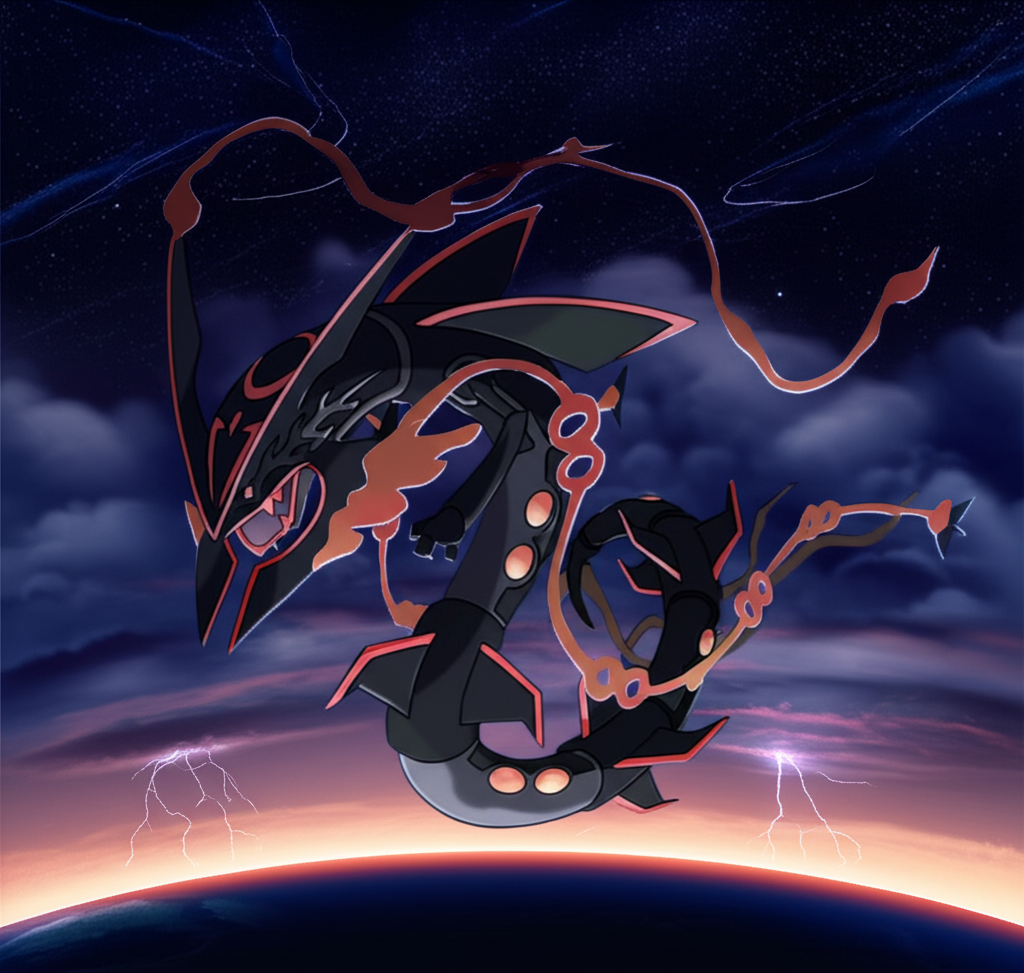

In [ ]:
import { GenerateContentResponse } from "@google/genai";

const IMAGE_GENERATION_MODEL_ID = "gemini-2.0-flash-preview-image-generation";

function displayResponse(response: GenerateContentResponse) {
  for (const part of response.candidates?.[0]?.content?.parts ?? []) {
    if (part.text) {
      tslab.display.markdown(part.text);
    } else if (part.inlineData) {
      const imageData = part.inlineData.data!;
      const buffer = Buffer.from(imageData, "base64");
      tslab.display.png(buffer);
    }
  }
}
const response = await ai.models.generateContent({
  model: IMAGE_GENERATION_MODEL_ID,
  contents: [
    `
    Include the supplied sprite as the main subject of the image, and generate a background that fits the sprite's aesthetics.

    Background:
    ${backgroundDescription.text ?? ""}
    `,
    google.createPartFromBase64(Buffer.from(await artworkBlob.arrayBuffer()).toString("base64"), "image/png"),
  ],
  config: {
    responseModalities: [google.Modality.TEXT, google.Modality.IMAGE],
  },
});

displayResponse(response);


## Summary

In this guide, you learned how to build a MCP server using the `modelcontextprotocol/typescript-sdk` SDK and how to connect it to a Gemini model. You also learned how to define tools for the MCP server, invoke them manually, and integrate them with a Gemini model. Finally, you explored multi-tool invocation, multi-step reasoning, and multi-modal output capabilities of the Gemini model.

## Next Steps

You can explore more advanced features of the MCP server, such as defining prompts and resources, or using the MCP server in a production environment. You can also experiment with different models and see how they perform with the MCP server. For more information, check out the [MCP documentation](https://modelcontextprotocol.io/docs/getting-started/intro).
